In [1]:
from matplotlib import pyplot as plt
import os
import cv2
Imgpath = os.path.join("D:", "controlling_behaviors_in_animals_and_robots", "cobar-2026", "Group13", "test_view_detection.jpg")

In [2]:
import numpy as np

def correct_barrel_distortion(img, strength=0.1):
    """
    Corrige la distorsion barrel (image courbée) en image plate.
    
    Args:
        img: image d'entrée
        strength: force de la correction (0.05-0.3). Plus élevé = plus de correction.
                  Valeurs négatives corrigent pincushion au lieu de barrel.
    
    Returns:
        img_corrected: image avec distorsion corrigée
    """
    h, w = img.shape[:2]
    
    # Créer une carte de transformation
    map_x = np.zeros((h, w), dtype=np.float32)
    map_y = np.zeros((h, w), dtype=np.float32)
    
    # Normaliser les coordonnées au centre de l'image [-1, 1]
    for y in range(h):
        for x in range(w):
            # Normaliser
            nx = (x - w/2) / (w/2)
            ny = (y - h/2) / (h/2)
            
            # Appliquer la correction barrel (radiale)
            r = np.sqrt(nx**2 + ny**2)
            correction_factor = 1 + strength * r**2
            
            # Nouvelles coordonnées
            new_x = (nx / correction_factor) * (w/2) + w/2
            new_y = (ny / correction_factor) * (h/2) + h/2
            
            map_x[y, x] = new_x
            map_y[y, x] = new_y
    
    # Appliquer la transformation
    img_corrected = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR)
    return img_corrected

def convert_fly_eyes_to_flat(img_vr, remove_black_borders=True, eye='left', 
                             overlap_handling='average', correct_distortion=False, distortion_strength=0.1):
    """
    Convertit une image d'yeux de mouche (2 yeux avec overlap au milieu) en image plate.
    
    Args:
        img_vr: image chargée
        remove_black_borders: si True, supprime les bords noirs
        eye: 'left', 'right', 'both', ou 'combined'
               - 'left': oeil gauche seul
               - 'right': oeil droit seul
               - 'both': moyenne des deux yeux (inclut l'overlap)
               - 'combined': fusion des deux yeux côte à côte sans overlap
        overlap_handling: 'average', 'left_priority', ou 'right_priority' (pour 'both')
        correct_distortion: si True, corrige la distorsion barrel
        distortion_strength: force de la correction (0.05-0.3)
    
    Returns:
        img_flat: image plate
    """
    h, w = img_vr.shape[:2]
    
    # Détecter le centre (zone d'overlap)
    mid = w // 2
    
    if eye == 'left':
        img_flat = img_vr[:, :mid]
    elif eye == 'right':
        img_flat = img_vr[:, mid:]
    elif eye == 'both':
        # Moyenner les deux yeux (inclut l'overlap)
        left_eye = img_vr[:, :mid].astype(float)
        right_eye = img_vr[:, mid:].astype(float)
        
        if overlap_handling == 'average':
            img_flat = cv2.addWeighted(img_vr[:, :mid], 0.5, img_vr[:, mid:], 0.5, 0)
        elif overlap_handling == 'left_priority':
            img_flat = img_vr[:, :mid]
        else:  # right_priority
            img_flat = img_vr[:, mid:]
    else:  # 'combined'
        # Retirer l'overlap et mettre côte à côte
        # Supprimer 25% de chaque côté au milieu pour éliminer l'overlap
        overlap_margin = w // 8
        left_eye = img_vr[:, :mid-overlap_margin]
        right_eye = img_vr[:, mid+overlap_margin:]
        
        # Redimensionner le droit pour qu'il ait la même largeur que le gauche
        if left_eye.shape[1] != right_eye.shape[1]:
            right_eye = cv2.resize(right_eye, (left_eye.shape[1], left_eye.shape[0]))
        
        # Concaténer horizontalement
        img_flat = np.hstack([left_eye, right_eye])
    
    # Corriger la distorsion si demandé
    if correct_distortion:
        img_flat = correct_barrel_distortion(img_flat, strength=distortion_strength)
    
    # Supprimer les bords noirs
    if remove_black_borders:
        if len(img_flat.shape) == 3:
            gray = cv2.cvtColor(img_flat, cv2.COLOR_BGR2GRAY)
        else:
            gray = img_flat
        
        # Trouver les pixels non-noirs
        _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            x, y, w_crop, h_crop = cv2.boundingRect(max(contours, key=cv2.contourArea))
            img_flat = img_flat[y:y+h_crop, x:x+w_crop]
    
    return img_flat

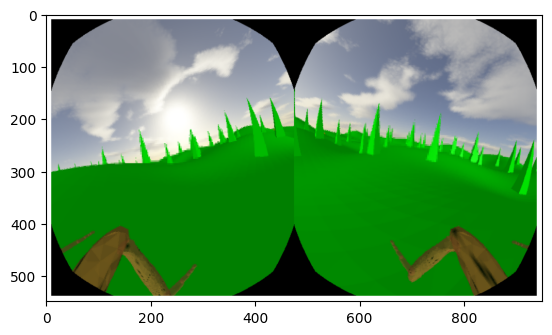

In [29]:
img = cv2.imread("D:\\controlling_behaviors_in_animals_and_robots\\cobar-2026\\Group13\\test_view_detection.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
#img = convert_fly_eyes_to_flat(img, eye='combined', remove_black_borders=True, correct_distortion=True, distortion_strength=0.15)
img2 = cv2.imread("D:\\controlling_behaviors_in_animals_and_robots\\cobar-2026\\Group13\\imageclosup.png")

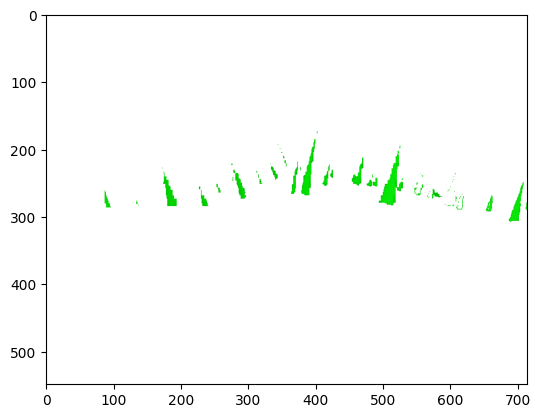

In [17]:
def filter_by_rgb_color(img_bgr, target_rgb, tolerance=30):
    """
    Filter image to show only pixels close to a target RGB color.
    Other pixels are set to white.
    
    Args:
        img_bgr: input image in BGR format
        target_rgb: tuple (R, G, B) of target color
        tolerance: color distance threshold (0-255)
    
    Returns:
        filtered image with matching pixels and white background
    """
    target_bgr = (target_rgb[2], target_rgb[1], target_rgb[0])  # Convert RGB to BGR
    
    # Calculate Euclidean distance from each pixel to target color
    dist = np.sqrt(np.sum((img_bgr.astype(float) - np.array(target_bgr)) ** 2, axis=2))
    
    # Create mask for pixels within tolerance
    mask = dist <= tolerance
    
    # Create output image (white background)
    result = np.ones_like(img_bgr) * 255
    result[mask] = img_bgr[mask]
    
    return result


# Example usage:rgba(0, 186, 0)
filtered = filter_by_rgb_color(img, target_rgb=(0, 220, 0), tolerance=30)
plt.imshow(cv2.cvtColor(filtered, cv2.COLOR_BGR2RGB))
plt.show()


In [32]:
def find_largest_white_stack(img, direction='left-to-right'):
    """
    Scans an image from left to right (or right to left) to find the column 
    with the largest vertical stack of white pixels.
    
    Args:
        img: Input image (numpy array). White pixels are assumed to be (255, 255, 255) or >200 in grayscale
        direction: 'left-to-right' or 'right-to-left'
    
    Returns:
        dict with keys:
            'column': x-coordinate of the largest white stack
            'max_stack_height': height of the largest consecutive white pixels in that column
            'start_row': starting row index of the largest stack
            'end_row': ending row index of the largest stack
    """
    # Convert to grayscale if it's a color image
    if len(img.shape) == 3:
        gray = np.mean(img, axis=2)
    else:
        gray = img
    
    # Create binary mask: white pixels (threshold > 200)
    binary = gray > 200
    
    height, width = binary.shape
    
    # Determine scan direction
    columns_to_scan = range(width-1, -1, -1) if direction == 'right-to-left' else range(width)
    
    max_height = 0
    best_column = 0
    best_start_row = 0
    best_end_row = 0
    
    # Scan each column
    for col in columns_to_scan:
        white_pixels = binary[:, col]
        
        # Find consecutive white pixels
        current_height = 0
        current_start = 0
        
        for row in range(height):
            if white_pixels[row]:
                if current_height == 0:
                    current_start = row
                current_height += 1
            else:
                if current_height > max_height:
                    max_height = current_height
                    best_column = col
                    best_start_row = current_start
                    best_end_row = row - 1
                current_height = 0
        
        # Check final segment
        if current_height > max_height:
            max_height = current_height
            best_column = col
            best_start_row = current_start
            best_end_row = height - 1
    
    return {
        'column': best_column,
        'max_stack_height': max_height,
        'start_row': best_start_row,
        'end_row': best_end_row
    }




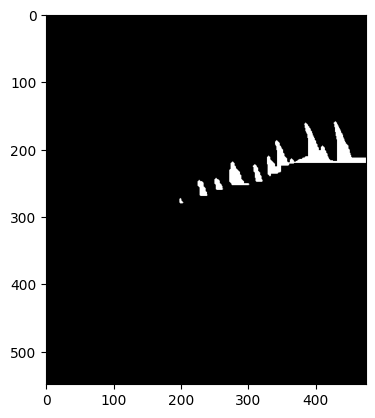

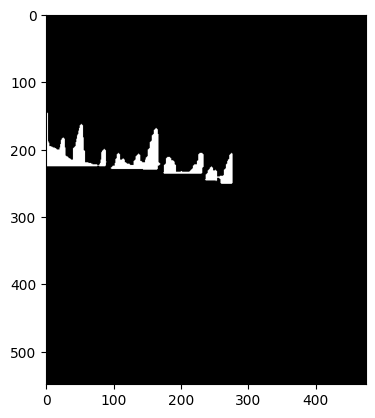

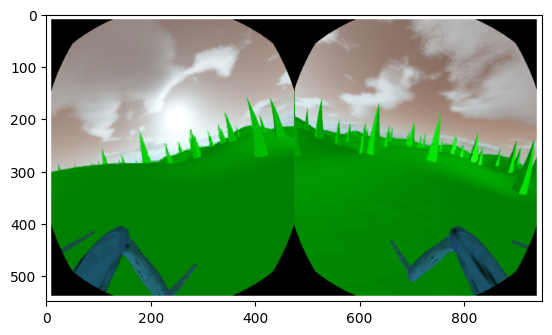

In [30]:
from spike_bin_from_vision import spike_bin_masks_from_raw_vision
test = img.copy()
spike_bins = spike_bin_masks_from_raw_vision(raw_vision=test,layout="concat_along_width")
plt.imshow(spike_bins["left"], cmap='gray')
plt.show()
plt.imshow(spike_bins["right"], cmap='gray')
plt.show()
plt.imshow(img, cmap='gray')

In [39]:
def find_largest_stack_from_base_img(img, direction='left-to-right', layout="concat_along_width",print_debug=False):
    spike_bins = spike_bin_masks_from_raw_vision(raw_vision=img,layout=layout)
    result = {}
    result['left'] = find_largest_white_stack(spike_bins["left"], direction=direction)
    result['right'] = find_largest_white_stack(spike_bins["right"], direction=direction)
    if print_debug:
        fig,ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))
        ax[0].imshow(spike_bins["left"], cmap='gray')
        ax[0].axvline(x=result['left']['column'], color='red', linewidth=2, label=f"Largest stack at column {result['left']['column']}")
        ax[0].axhline(y=result['left']['start_row'], color='yellow', linewidth=1, linestyle='--', alpha=0.7)
        ax[0].axhline(y=result['left']['end_row'], color='yellow', linewidth=1, linestyle='--', alpha=0.7)
        ax[0].set_title(f"Largest Vertical White Stack: {result['left']['max_stack_height']} pixels")
        ax[1].imshow(spike_bins["right"], cmap='gray')
        ax[1].axvline(x=result['right']['column'], color='red', linewidth=2, label=f"Largest stack at column {result['right']['column']}")
        ax[1].axhline(y=result['right']['start_row'], color='yellow', linewidth=1, linestyle='--', alpha=0.7)
        ax[1].axhline(y=result['right']['end_row'], color='yellow', linewidth=1, linestyle='--', alpha=0.7)
        ax[1].set_title(f"Largest Vertical White Stack: {result['right']['max_stack_height']} pixels")
    return result

{'left': {'column': 432,
  'max_stack_height': 58,
  'start_row': 163,
  'end_row': 220},
 'right': {'column': 0,
  'max_stack_height': 81,
  'start_row': 145,
  'end_row': 225}}

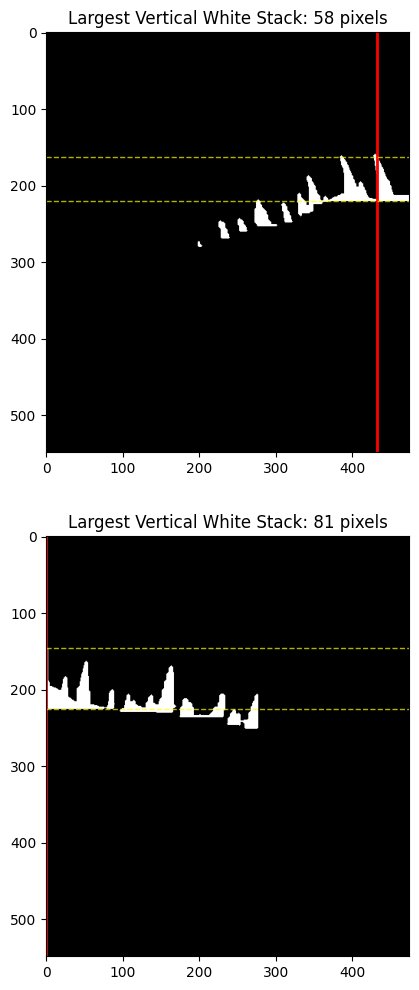

In [40]:
find_largest_stack_from_base_img(img, direction='left-to-right', layout="concat_along_width", print_debug=True)

Largest white pixel stack found:
  Column: 432
  Height: 58 pixels
  Rows: 163 to 220


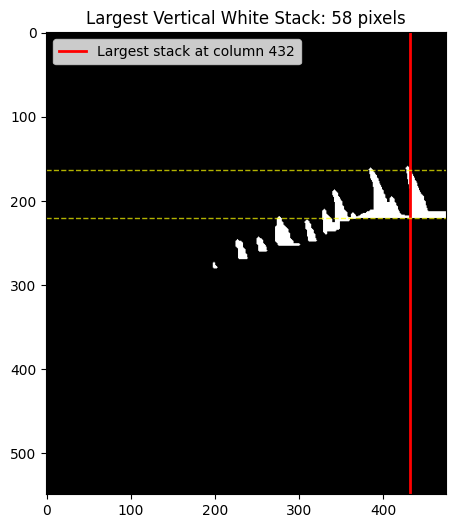

Largest white pixel stack found:
  Column: 0
  Height: 81 pixels
  Rows: 145 to 225


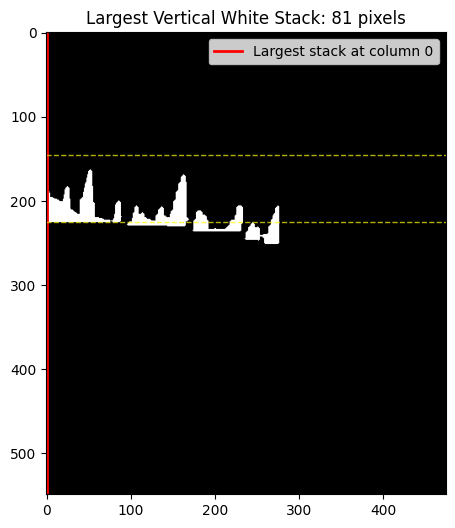

In [34]:
# Test the function
result = find_largest_white_stack(spike_bins["left"], direction='left-to-right')
print(f"Largest white pixel stack found:")
print(f"  Column: {result['column']}")
print(f"  Height: {result['max_stack_height']} pixels")
print(f"  Rows: {result['start_row']} to {result['end_row']}")

# Visualize the result
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(spike_bins["left"], cmap='gray')
ax.axvline(x=result['column'], color='red', linewidth=2, label=f"Largest stack at column {result['column']}")
ax.axhline(y=result['start_row'], color='yellow', linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(y=result['end_row'], color='yellow', linewidth=1, linestyle='--', alpha=0.7)
ax.set_title(f"Largest Vertical White Stack: {result['max_stack_height']} pixels")
ax.legend()
plt.show()
result = find_largest_white_stack(spike_bins["right"], direction='left-to-right')
print(f"Largest white pixel stack found:")
print(f"  Column: {result['column']}")
print(f"  Height: {result['max_stack_height']} pixels")
print(f"  Rows: {result['start_row']} to {result['end_row']}")

# Visualize the result
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.imshow(spike_bins["right"], cmap='gray')
ax.axvline(x=result['column'], color='red', linewidth=2, label=f"Largest stack at column {result['column']}")
ax.axhline(y=result['start_row'], color='yellow', linewidth=1, linestyle='--', alpha=0.7)
ax.axhline(y=result['end_row'], color='yellow', linewidth=1, linestyle='--', alpha=0.7)
ax.set_title(f"Largest Vertical White Stack: {result['max_stack_height']} pixels")
ax.legend()
plt.show()

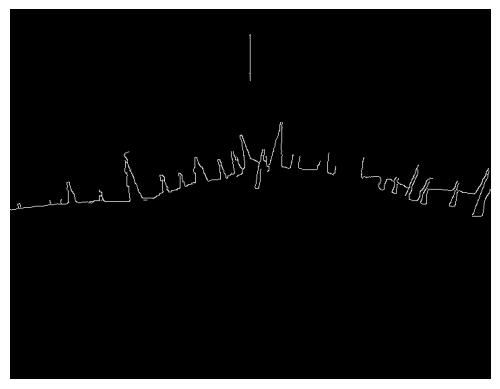

In [48]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
canny = cv2.Canny(blur, 64, 188)
plt.imshow(canny, cmap='gray')
plt.axis('off')
plt.show()

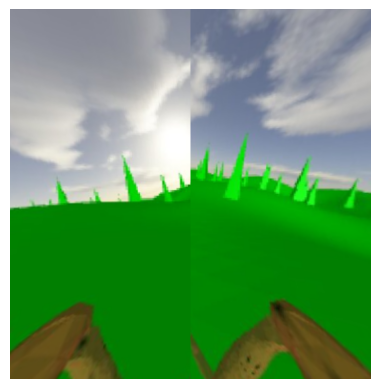

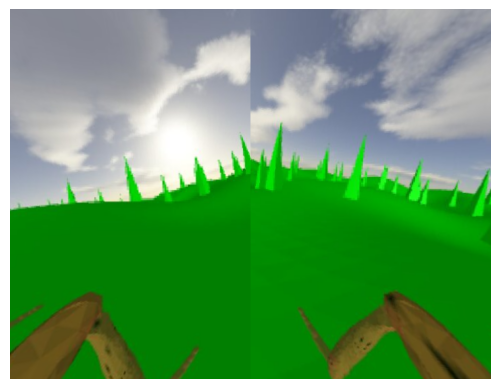

In [102]:
new = convert_fly_eyes_to_flat(img, eye='combined', remove_black_borders=True, correct_distortion=True, distortion_strength=0.15)
plt.imshow(cv2.cvtColor(new, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


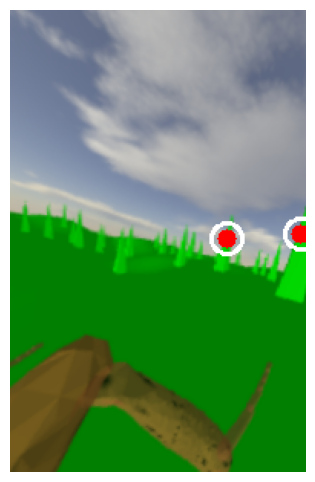

In [100]:
import cv2
import numpy as np

previous_img = img.copy()
img = convert_fly_eyes_to_flat(previous_img, eye='combined',
                               remove_black_borders=True,
                               correct_distortion=True,
                               distortion_strength=0.15)
H, W = img.shape[:2]
left = img[:, : W // 2]
right = img[:, W // 2 :]

H, W = left.shape[:2]
hsv = cv2.cvtColor(left, cv2.COLOR_BGR2HSV)

lower_green = np.array([35, 30, 30])
upper_green = np.array([95, 255, 255])
mask_green = cv2.inRange(hsv, lower_green, upper_green)

k_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, k_small, iterations=1)
mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, k_small, iterations=2)

# IMPORTANT: n’enlève PAS toute la bande du bas
ignore = np.zeros((H, W), np.uint8)
ignore[int(0.80*H):, :int(0.18*W)] = 255
ignore[int(0.80*H):, int(0.82*W):] = 255
mask_green[ignore > 0] = 0

# Sol = version "lissée" qui enlève les objets fins (brins)
k_big = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (45, 45))  # à ajuster selon résolution
ground_mask = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, k_big, iterations=1)
ground_mask = cv2.morphologyEx(ground_mask, cv2.MORPH_CLOSE, k_big, iterations=1)

# Brins = vert - sol
spikes_mask = cv2.subtract(mask_green, ground_mask)
spikes_mask = cv2.morphologyEx(spikes_mask, cv2.MORPH_OPEN, k_small, iterations=1)

# Composantes = obstacles + centres
n, lab, st, cen = cv2.connectedComponentsWithStats(spikes_mask, connectivity=8)

obstacles = []
for i in range(1, n):
    x, y, w, h, area = st[i]
    if area < 20: 
        continue
    if h < 12:
        continue
    if h / (w + 1e-6) < 2.0:
        continue
    cx, cy = cen[i]
    obstacles.append((int(cx), int(cy)))

centers = obstacles
overlay = left.copy()

for (cx, cy) in centers:
    cv2.circle(overlay, (cx, cy), 6, (0, 0, 255), -1)      
    cv2.circle(overlay, (cx, cy), 10, (255, 255, 255), 2)  

# Affichage (notebook)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [116]:
img = cv2.imread("D:/controlling_behaviors_in_animals_and_robots/cobar-2026/Group13/imageclosup.png")

In [117]:
import cv2
import numpy as np


def detect_spike_centers_single_eye(
    img_bgr: np.ndarray,
    *,
    # Vert (HSV) — à ajuster si ton rendu change beaucoup
    hsv_green_low=(33, 25, 25),
    hsv_green_high=(95, 255, 255),
    # Pattes : coins bas-gauche / bas-droite uniquement (évite de supprimer tout le bas)
    ignore_bottom_frac=0.82,
    ignore_side_frac=0.20,
    # Morpho “sol sans spikes” : proportionnel à la taille de l’image
    ground_open_frac_of_min_side=0.065,  # ~41px pour min_side≈630 (à ajuster)
    ground_open_min=21,
    ground_open_max=81,
    ground_open_must_be_odd=True,
    # Séparation des pics (distance transform)
    min_peak_radius_px=2.5,          # ignore les pics trop petits (bruit)
    local_max_window_px=9,           # fenêtre des maxima locaux (impair)
    # Anti-doublons entre pics voisins
    nms_min_dist_px=None,            # None => auto ~ local_max_window_px
    # Debug
    return_debug_masks=False,
):
    img_bgr = img_bgr.copy()
    H, W = img_bgr.shape[:2]
    min_side = min(H, W)

    # --- 1) Masque vert ---
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    low = np.array(hsv_green_low, dtype=np.uint8)
    high = np.array(hsv_green_high, dtype=np.uint8)
    mask_green = cv2.inRange(hsv, low, high)

    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, k3, iterations=1)
    mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, k3, iterations=1)

    # --- 2) Masquer pattes (coins bas) ---
    ignore = np.zeros((H, W), np.uint8)
    y0 = int(ignore_bottom_frac * H)
    ignore[y0:, : int(ignore_side_frac * W)] = 255
    ignore[y0:, int((1.0 - ignore_side_frac) * W) :] = 255
    mask_green = cv2.bitwise_and(mask_green, cv2.bitwise_not(ignore))

    # --- 3) Sol ≈ opening large (enlève les objets fins / spikes) ---
    open_sz = int(round(ground_open_frac_of_min_side * min_side))
    open_sz = max(ground_open_min, min(ground_open_max, open_sz))
    if ground_open_must_be_odd and (open_sz % 2 == 0):
        open_sz += 1
    k_big = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_sz, open_sz))
    ground_mask = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, k_big, iterations=1)
    ground_mask = cv2.morphologyEx(ground_mask, cv2.MORPH_CLOSE, k_big, iterations=1)

    # --- 4) Spikes = ce qui n’est pas “sol lisse” ---
    spikes_mask = cv2.subtract(mask_green, ground_mask)
    spikes_bin = (spikes_mask > 0).astype(np.uint8)

    # léger dilate pour reconnecter la silhouette utile si besoin
    spikes_bin = cv2.dilate(spikes_bin, k3, iterations=1)

    # --- 5) Pics locaux sur distance transform ---
    if spikes_bin.max() == 0:
        centers = []
        if return_debug_masks:
            return centers, {
                "mask_green": mask_green,
                "ground_mask": ground_mask,
                "spikes_mask": spikes_mask,
                "spikes_bin": spikes_bin,
                "dist": np.zeros((H, W), np.float32),
            }
        return centers

    dist = cv2.distanceTransform(spikes_bin, cv2.DIST_L2, 5)

    w = int(local_max_window_px)
    if w % 2 == 0:
        w += 1
    local_max_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (w, w))
    local_max = cv2.compare(dist, cv2.dilate(dist, local_max_kernel), cv2.CMP_EQ)

    peaks = (local_max > 0) & (dist >= float(min_peak_radius_px))
    ys, xs = np.where(peaks)

    points = np.stack([xs, ys], axis=1) if len(xs) else np.zeros((0, 2), np.int32)
    scores = dist[ys, xs] if len(xs) else np.zeros((0,), np.float32)

    # --- 6) NMS (garde les pics les plus “forts”, éloigne les doublons) ---
    min_dist = nms_min_dist_px
    if min_dist is None:
        min_dist = float(w)

    # tri décroissant par score (rayon local)
    order = np.argsort(-scores)
    kept = []
    kept_scores = []
    for idx in order:
        x, y = int(points[idx, 0]), int(points[idx, 1])
        s = float(scores[idx])
        ok = True
        for (kx, ky) in kept:
            if (x - kx) ** 2 + (y - ky) ** 2 < min_dist ** 2:
                ok = False
                break
        if ok:
            kept.append((x, y))
            kept_scores.append(s)

    centers = kept

    if return_debug_masks:
        dbg = {
            "mask_green": mask_green,
            "ground_mask": ground_mask,
            "spikes_mask": spikes_mask,
            "spikes_bin": (spikes_bin * 255).astype(np.uint8),
            "dist": dist,
            "peaks_raw": (peaks.astype(np.uint8) * 255),
        }
        return centers, dbg

    return centers


def draw_centers_overlay(img_bgr, centers, *, radius=6):
    out = img_bgr.copy()
    for (x, y) in centers:
        cv2.circle(out, (int(x), int(y)), radius, (0, 0, 255), -1)
        cv2.circle(out, (int(x), int(y)), radius + 4, (255, 255, 255), 2)
    return out

In [118]:
img = convert_fly_eyes_to_flat(img, eye='combined',
                               remove_black_borders=True,
                               correct_distortion=True,
                               distortion_strength=0.15)

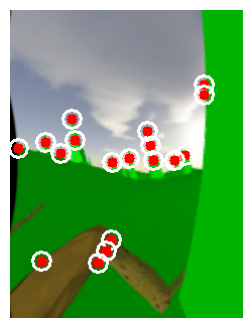

nb centers: 18


In [119]:

H, W = img.shape[:2]
eye = img[:, :W//2]   # ou img[:, W//2:] pour l’autre oeil

centers, dbg = detect_spike_centers_single_eye(
    eye,
    hsv_green_low=(33, 20, 20),
    hsv_green_high=(100, 255, 255),

    ignore_bottom_frac=0.82,
    ignore_side_frac=0.22,

    # sol: min_side ≈ 357 → 0.055*357 ≈ 20 px (impair → 21)
    ground_open_frac_of_min_side=0.055,
    ground_open_min=19,
    ground_open_max=51,

    # pics: brins lointains petits → seuil bas
    min_peak_radius_px=1.8,
    local_max_window_px=7,   # 7 ou 9
    nms_min_dist_px=10,      # évite doublons
    return_debug_masks=True,
)

overlay = draw_centers_overlay(eye, centers, radius=5)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print("nb centers:", len(centers))

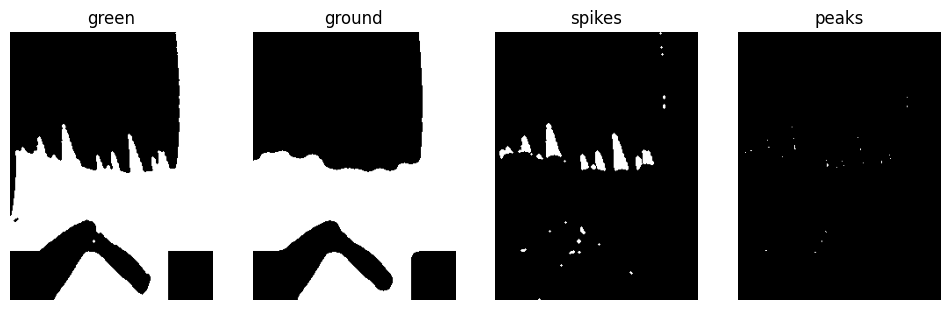

In [120]:
plt.figure(figsize=(12,12))
plt.subplot(1,4,1); plt.title("green");  plt.imshow(dbg["mask_green"], cmap="gray"); plt.axis("off")
plt.subplot(1,4,2); plt.title("ground"); plt.imshow(dbg["ground_mask"], cmap="gray"); plt.axis("off")
plt.subplot(1,4,3); plt.title("spikes"); plt.imshow(dbg["spikes_bin"], cmap="gray"); plt.axis("off")
plt.subplot(1,4,4); plt.title("peaks");  plt.imshow(dbg["peaks_raw"], cmap="gray"); plt.axis("off")
plt.show()

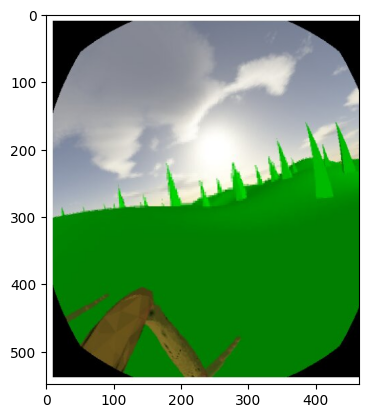

In [24]:
eye = extract_eyes_rect(img, remove_black_borders=True, overlap_margin=10)[0]  # extraire l'oeil gauche
img_cropped = crop_black_borders(eye)
plt.imshow(cv2.cvtColor(img_cropped, cv2.COLOR_BGR2RGB))

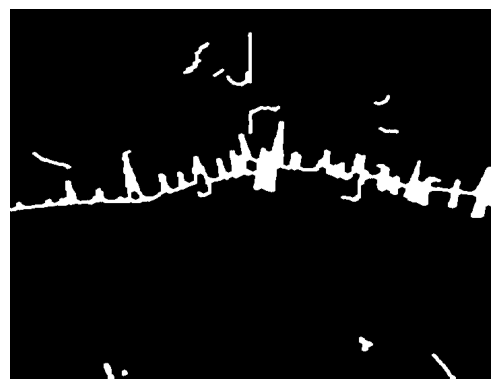

52.5
190.5
234.5
220.0
260.5
120.5
15368.0
346.0
115.5
67.5
353.0
533.0


(np.float64(-0.5), np.float64(713.5), np.float64(548.5), np.float64(-0.5))

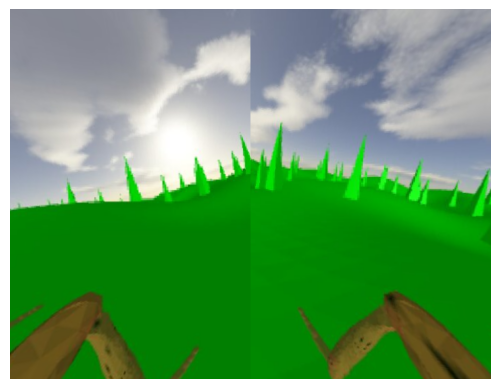

In [80]:
import cv2
import numpy as np

img = img.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur,50, 100)

# épaissir + fermer pour connecter les segments
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
edges2 = cv2.dilate(edges, kernel, iterations=1)
edges2 = cv2.morphologyEx(edges2, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(edges2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
plt.imshow(edges2, cmap='gray')
plt.axis('off')
plt.show()
triangles = []
centers = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    print(area)
    if area < 300:   # à adapter
        continue

    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)  # epsilon à ajuster

    if len(approx) == 3 and cv2.isContourConvex(approx):
        # centroïde
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            triangles.append(cnt)
            centers.append((cx, cy))

img_triangles = img.copy()
for tri in triangles:
    cv2.drawContours(img_triangles, [tri], -1, (0, 255, 0), 2)
for center in centers:
    cv2.circle(img_triangles, center, 5, (255, 0, 0), -1)
plt.imshow(cv2.cvtColor(img_triangles, cv2.COLOR_BGR2RGB))
plt.axis('off')


In [78]:
print(triangles)

[]
